In [ ]:
import pandas as pd

users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")
follows = pd.read_csv("follows.csv")

print("Users")
print(users.columns.tolist())

print("\nPhotos")
print(photos.columns.tolist())

print("\nLikes")
print(likes.columns.tolist())

print("\nComments")
print(comments.columns.tolist())

print("\nTags")
print(tags.columns.tolist())

print("\nPhoto Tags")
print(photo_tags.columns.tolist())

print("\nFollows")
print(follows.columns.tolist())

Users
['id', 'name', 'created time', 'private/public', 'post count', 'Verified status']

Photos
['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']

Likes
['user ', 'photo', 'created time', 'following or not', 'like type']

Comments
['id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'Hashtags used count']

Tags
['id', 'tag text', 'created time', 'location']

Photo Tags
['photo', 'tag ID', 'user id']

Follows
['follower', 'followee ', 'created time', 'is follower active', 'followee Acc status']


Instagram Engagement Analysis

Objective

The objective of this project is to analyze Instagram user activity, post engagement, hashtags, and posting behavior to identify factors that improve engagement. The analysis also provides recommendations and an optimal content strategy for Alfido Tech.

In [ ]:
!pip install seaborn

Import Required Libraries

This step imports the Python libraries required for data analysis, visualization, and data preprocessing.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

Import Google Colab Files Module

The Google Colab files module is imported to upload the Instagram dataset into the notebook.

In [ ]:
from google.colab import files

Upload Instagram Dataset

All required CSV files are uploaded into the Google Colab environment for analysis.

In [ ]:
uploaded = files.upload()

Saving users.csv to users (1).csv
Saving tags.csv to tags (1).csv
Saving photos.csv to photos (1).csv
Saving photo_tags.csv to photo_tags (1).csv
Saving likes.csv to likes (1).csv
Saving follows.csv to follows (1).csv
Saving comments.csv to comments (1).csv


Load the Datasets

All Instagram dataset files are loaded into Pandas DataFrames for further analysis.

In [ ]:
users = pd.read_csv("users.csv")

photos = pd.read_csv("photos.csv")

likes = pd.read_csv("likes.csv")

comments = pd.read_csv("comments.csv")

tags = pd.read_csv("tags.csv")

photo_tags = pd.read_csv("photo_tags.csv")

follows = pd.read_csv("follows.csv")

Check Dataset Information

The structure, data types, and available records of each dataset are displayed for verification.

In [ ]:
users.head()
photos.head()
print("Likes")

display(likes.head())

print("Comments")

display(comments.head())

print("Tags")

display(tags.head())

print("Photo Tags")

display(photo_tags.head())

print("Follows")

display(follows.head())
print(users.info())

print(photos.info())

print(likes.info())

print(comments.info())

print(tags.info())

print(photo_tags.info())

print(follows.info())

Likes


,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


Comments


,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


Tags


...

Photo Tags


,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


Follows


,follower,followee,created time,is follower active,followee Acc status
0,2,1,13-04-2023 08:04,1,Private
1,2,3,13-04-2023 08:04,0,private
2,2,4,13-04-2023 08:04,0,public
3,2,5,13-04-2023 08:04,0,private
4,2,6,13-04-2023 08:04,1,private


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               100 non-null    int64 
 1   name             100 non-null    object
 2   created time     100 non-null    object
 3   private/public   100 non-null    object
 4   post count       100 non-null    int64 
 5   Verified status  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 257 non-null    int64 
 1   image link         257 non-null    object
 2   user ID            257 non-null    int64 
 3   created dat        257 non-null    object
 4   Insta filter used  257 non-null    object
 5   photo type         257 non-null    object
dt

Check Missing Values

Missing values in each dataset are identified to ensure data quality before performing the analysis.

In [ ]:
print(users.isnull().sum())

print()

print(photos.isnull().sum())

print()

print(likes.isnull().sum())

print()

print(comments.isnull().sum())

print()

print(tags.isnull().sum())

print()

print(photo_tags.isnull().sum())

print()

print(follows.isnull().sum())

id                 0
name               0
created time       0
private/public     0
post count         0
Verified status    0
dtype: int64

id                   0
image link           0
user ID              0
created dat          0
Insta filter used    0
photo type           0
dtype: int64

user                0
photo               0
created time        0
following or not    0
like type           0
dtype: int64

id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hashtags used count    0
dtype: int64

id              0
tag text        0
created time    0
location        0
dtype: int64

photo      0
tag ID     0
user id    0
dtype: int64

follower               0
followee               0
created time           0
is follower active     0
followee Acc status    0
dtype: int64


Display Dataset Shapes

The dimensions of all datasets are displayed to understand the number of records and attributes available for analysis.

In [ ]:
print("Users :", users.shape)

print("Photos :", photos.shape)

print("Likes :", likes.shape)

print("Comments :", comments.shape)

print("Tags :", tags.shape)

print("Photo Tags :", photo_tags.shape)

print("Follows :", follows.shape)

Users : (100, 6)
Photos : (257, 6)
Likes : (8782, 5)
Comments : (7488, 8)
Tags : (21, 4)
Photo Tags : (501, 3)
Follows : (7623, 5)


Convert Date Columns

The date and time columns are converted into datetime format to enable time-based analysis and extraction of useful features.

In [ ]:
photos["created dat"] = pd.to_datetime(
    photos["created dat"],
    errors="coerce"
)

comments["posted date"] = pd.to_datetime(
    comments["posted date"],
    errors="coerce"
)

photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo


Extract Posting Year, Month, and Day

The year, month, and day are extracted from the posting date to support trend analysis and content scheduling.

In [ ]:
photos["Year"] = photos["created dat"].dt.year

photos["Month"] = photos["created dat"].dt.month_name()

photos["Day"] = photos["created dat"].dt.day_name()

photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type,Year,Month,Day
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday


Calculate Total Likes Per Photo

The total number of likes received by each photo is calculated by grouping the likes dataset.

In [ ]:
like_count = likes.groupby(
    "photo"
).size().reset_index(
    name="Total Likes"
)

like_count.head()

,photo,Total Likes
0,1,25
1,2,36
2,3,38
3,4,38
4,5,31


Calculate Total Comments Per Photo

The total number of comments for each photo is calculated to measure audience interaction.

In [ ]:
comment_count = comments.groupby(
    "Photo id"
).size().reset_index(
    name="Total Comments"
)

comment_count.head()

,Photo id,Total Comments
0,1,25
1,2,31
2,3,27
3,4,32
4,5,27


Merge Like Counts with Photos

The calculated like counts are merged with the photos dataset to associate engagement with each post.

In [ ]:
photos = photos.merge(
    like_count,
    left_on="id",
    right_on="photo",
    how="left"
)

photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type,Year,Month,Day,photo,Total Likes
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday,1,25
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,2,36
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,3,38
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,4,38
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday,5,31


Merge Comment Counts with Photos

The calculated comment counts are merged with the photos dataset for complete engagement analysis.

In [ ]:
photos = photos.merge(
    comment_count,
    left_on="id",
    right_on="Photo id",
    how="left"
)

photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type,Year,Month,Day,photo,Total Likes,Photo id,Total Comments
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday,1,25,1,25
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,2,36,2,31
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,3,38,3,27
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,4,38,4,32
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday,5,31,5,27


Replace Missing Values

Missing values generated after merging are replaced with zero because posts with no likes or comments should be counted as zero engagement.

In [ ]:
photos["Total Likes"] = photos[
    "Total Likes"
].fillna(0)

photos["Total Comments"] = photos[
    "Total Comments"
].fillna(0)

photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type,Year,Month,Day,photo,Total Likes,Photo id,Total Comments
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday,1,25,1,25
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,2,36,2,31
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,3,38,3,27
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,4,38,4,32
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday,5,31,5,27


Calculate Engagement Score

The engagement score is calculated by combining the total number of likes and comments for each Instagram post.

In [ ]:
photos["Engagement"] = (

    photos["Total Likes"]

    +

    photos["Total Comments"]

)

photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type,Year,Month,Day,photo,Total Likes,Photo id,Total Comments,Engagement
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday,1,25,1,25,50
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,2,36,2,31,67
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,3,38,3,27,65
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,2023,April,Thursday,4,38,4,32,70
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,2023,April,Thursday,5,31,5,27,58


Display Engagement Summary

Basic statistical information of likes, comments, and engagement is displayed to understand user interaction across all posts.

In [ ]:
photos[

    [

        "Total Likes",

        "Total Comments",

        "Engagement"

    ]

].describe()

,Total Likes,Total Comments,Engagement
count,257.000000,257.000000,257.000000
mean,34.171206,29.136187,63.307393
std,3.605804,3.452939,4.810761
min,25.000000,21.000000,50.000000
25%,31.000000,27.000000,60.000000
50%,34.000000,29.000000,63.000000
75%,37.000000,31.000000,66.000000
max,48.000000,39.000000,79.000000


Analyze the Most Liked Posts

This visualization identifies the top 10 Instagram posts that received the highest number of likes. It helps understand which posts generated the greatest audience interest.

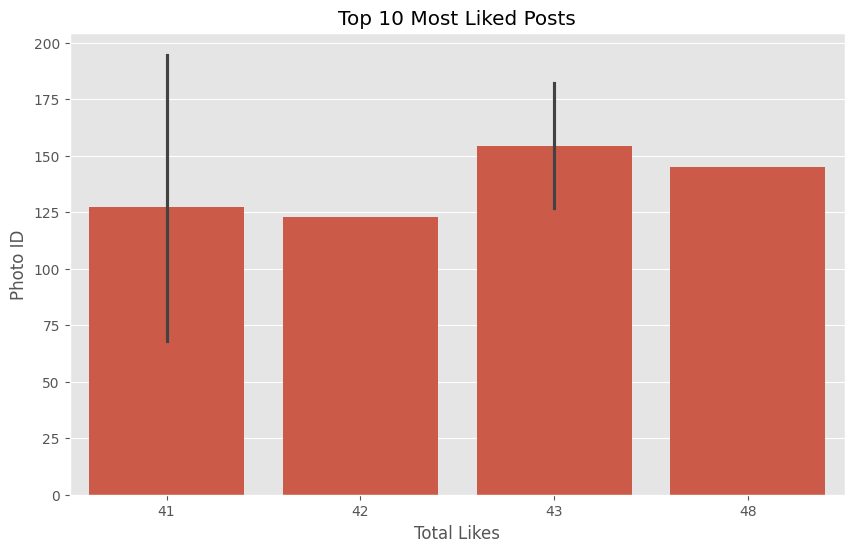

In [ ]:
top_likes = photos.sort_values(
    by="Total Likes",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Total Likes",
    y="id",
    data=top_likes
)

plt.title("Top 10 Most Liked Posts")

plt.xlabel("Total Likes")

plt.ylabel("Photo ID")

plt.show()

Analyze the Most Commented Posts

The top 10 posts with the highest number of comments are displayed to identify content that encouraged audience interaction.

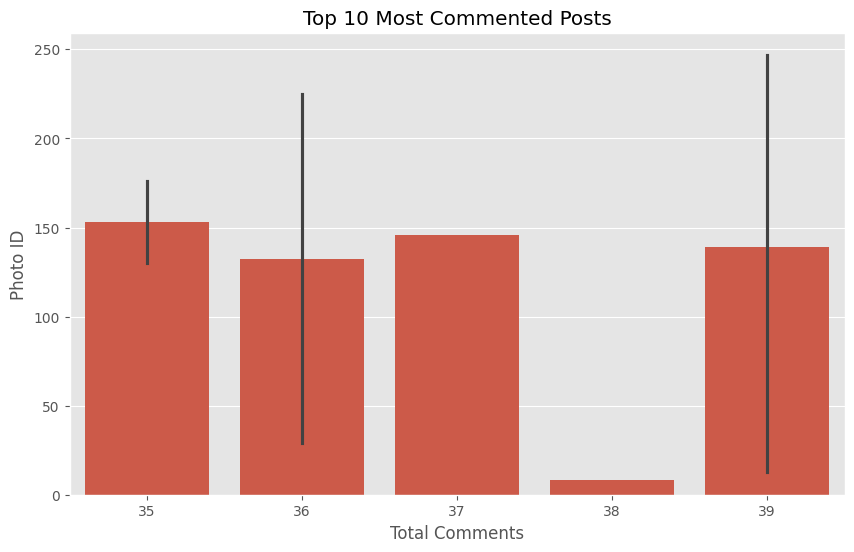

In [ ]:
top_comments = photos.sort_values(
    by="Total Comments",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Total Comments",
    y="id",
    data=top_comments
)

plt.title("Top 10 Most Commented Posts")

plt.xlabel("Total Comments")

plt.ylabel("Photo ID")

plt.show()

Analyze Content Types

The distribution of different Instagram content types is visualized to understand which type of content is posted most frequently.

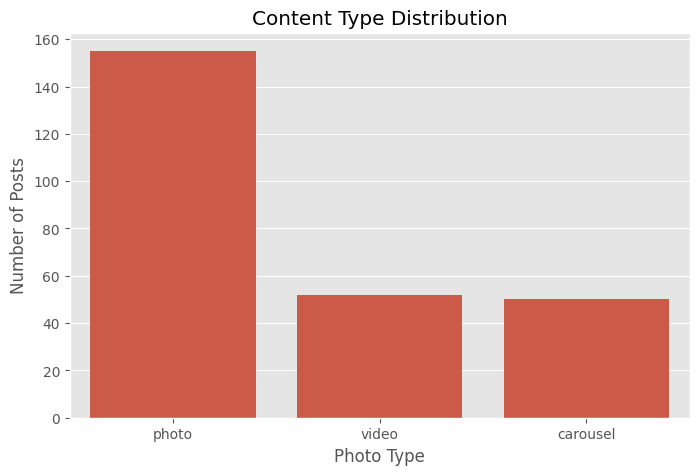

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="photo type",
    data=photos
)

plt.title("Content Type Distribution")

plt.xlabel("Photo Type")

plt.ylabel("Number of Posts")

plt.show()

Analyze Average Engagement by Content Type

The average engagement score for each content type is calculated to determine which type of content performs better.

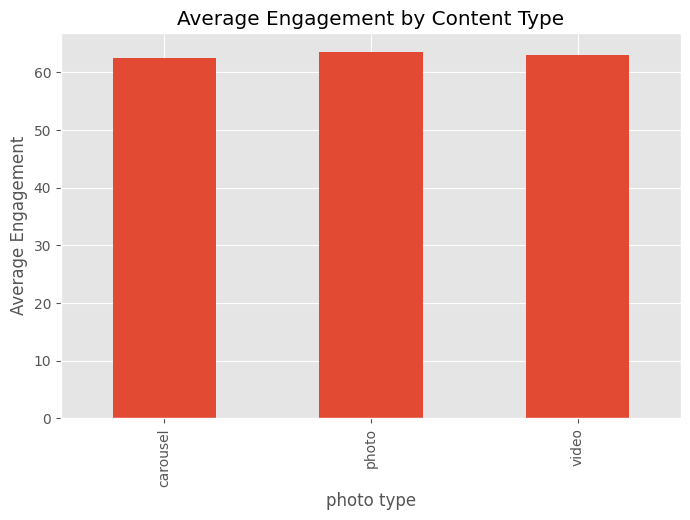

In [ ]:
engagement = photos.groupby(
    "photo type"
)["Engagement"].mean()

plt.figure(figsize=(8,5))

engagement.plot(kind="bar")

plt.title("Average Engagement by Content Type")

plt.ylabel("Average Engagement")

plt.show()

Analyze Posting Days

This visualization shows on which day of the week users post most frequently.

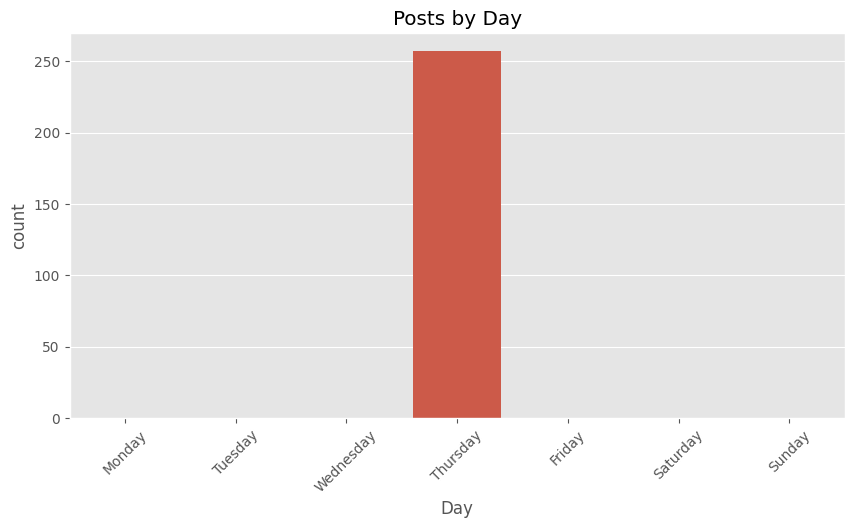

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Day",
    data=photos,
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]
)

plt.xticks(rotation=45)

plt.title("Posts by Day")

plt.show()

Analyze Monthly Posting Trend

The monthly distribution of posts helps identify seasonal posting trends and user activity.

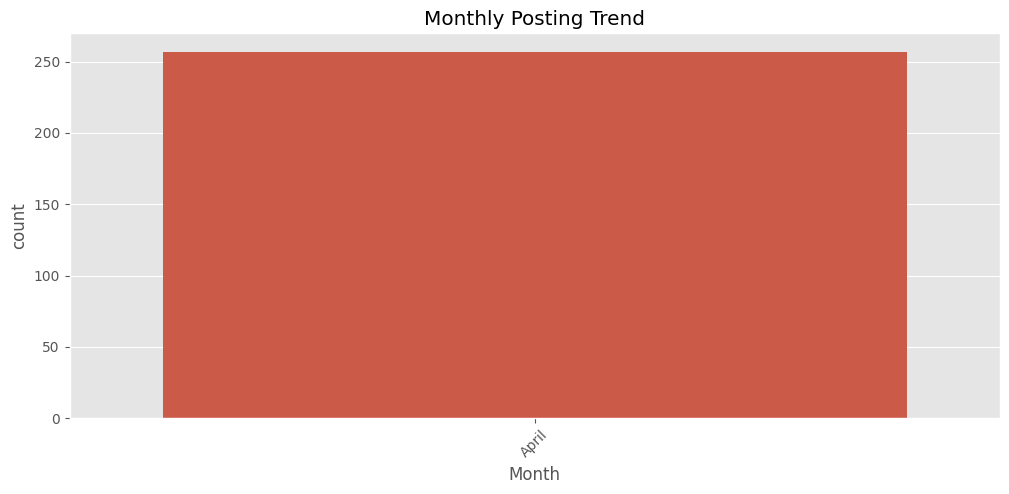

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="Month",
    data=photos
)

plt.xticks(rotation=45)

plt.title("Monthly Posting Trend")

plt.show()

Analyze Popular Hashtags

The most frequently used hashtags are identified to understand trending topics among Instagram users.

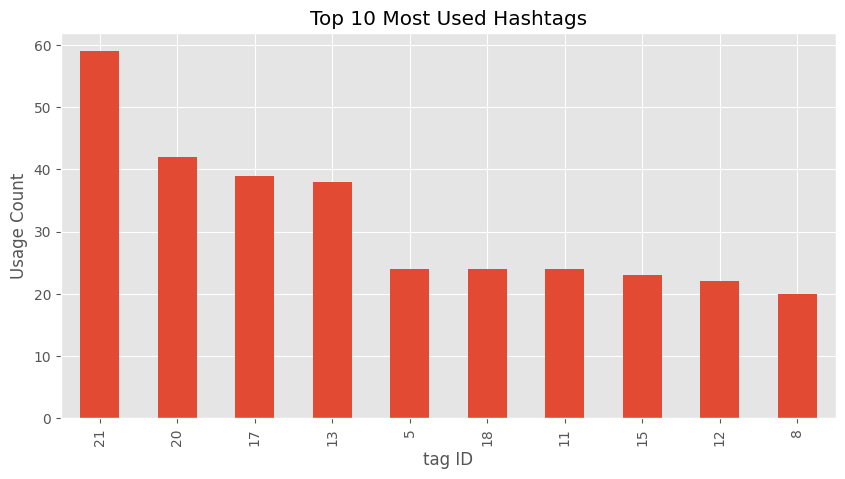

In [ ]:
top_tags = photo_tags.groupby(
    "tag ID"
).size().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

top_tags.plot(kind="bar")

plt.title("Top 10 Most Used Hashtags")

plt.ylabel("Usage Count")

plt.show()

Analyze Most Active Users

The users with the highest number of posts are identified to understand content creation activity.

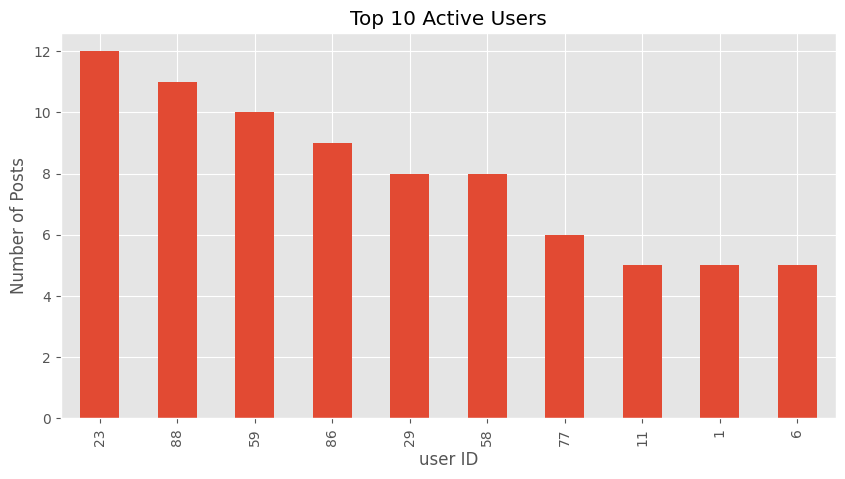

In [ ]:
active_users = photos.groupby(
    "user ID"
).size().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

active_users.plot(kind="bar")

plt.title("Top 10 Active Users")

plt.ylabel("Number of Posts")

plt.show()

Analyze Correlation Between Engagement Metrics

A correlation heatmap is created to examine relationships among likes, comments, and engagement score.

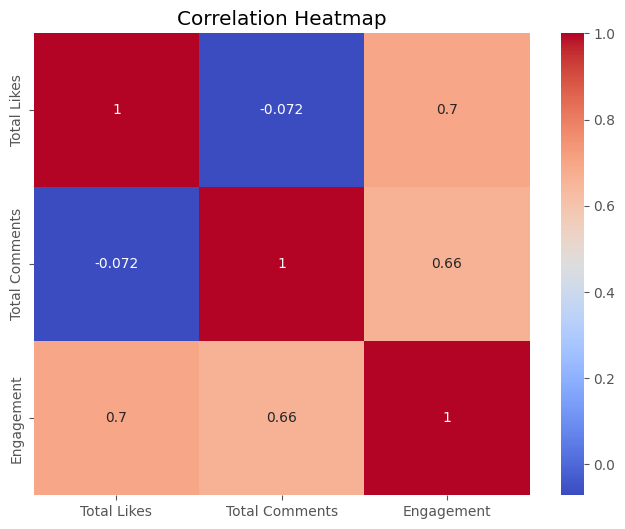

In [ ]:
plt.figure(figsize=(8,6))

numeric = photos[
    [
        "Total Likes",
        "Total Comments",
        "Engagement"
    ]
]

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Display Top Performing Posts

The top-performing Instagram posts are displayed based on their overall engagement score.

In [ ]:
photos.sort_values(
    by="Engagement",
    ascending=False
)[
    [
        "id",
        "photo type",
        "Total Likes",
        "Total Comments",
        "Engagement"
    ]
].head(10)

,id,photo type,Total Likes,Total Comments,Engagement
12,13,photo,40,39,79
144,145,video,48,27,75
146,147,photo,41,34,75
117,118,photo,39,35,74
226,227,photo,39,35,74
195,196,photo,38,35,73
224,225,video,37,36,73
126,127,photo,43,30,73
122,123,photo,42,31,73
152,153,photo,40,32,72


Analyze User Verification Status

This visualization compares verified and non-verified users to understand the distribution of verified accounts in the dataset.

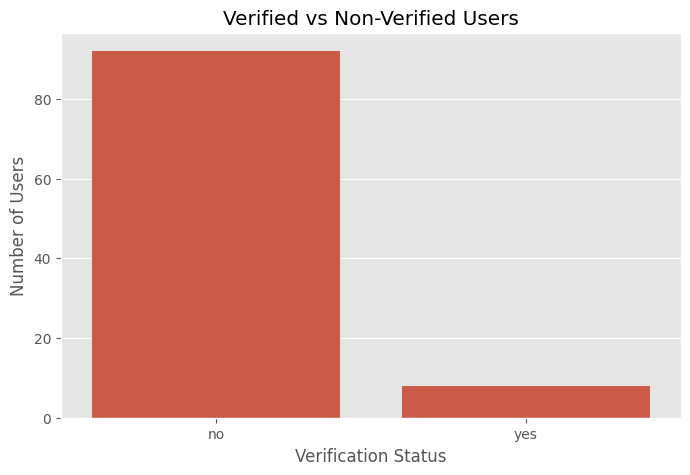

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Verified status",
    data=users
)

plt.title("Verified vs Non-Verified Users")

plt.xlabel("Verification Status")

plt.ylabel("Number of Users")

plt.show()

Analyze Public and Private Accounts

The distribution of public and private Instagram accounts is analyzed to understand account visibility.

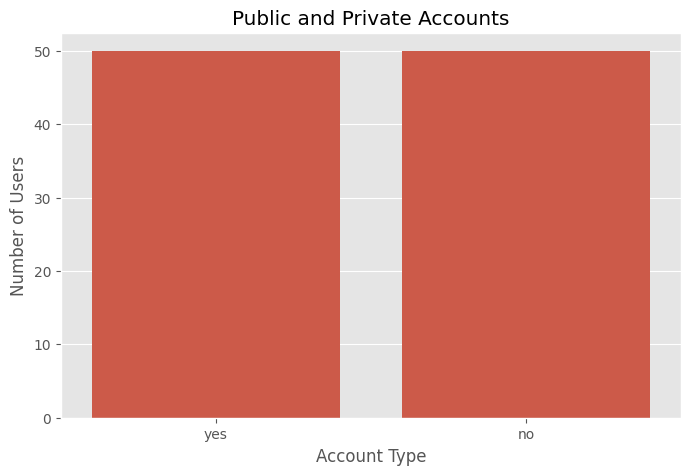

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="private/public",
    data=users
)

plt.title("Public and Private Accounts")

plt.xlabel("Account Type")

plt.ylabel("Number of Users")

plt.show()

Analyze User Post Counts

This visualization shows the distribution of posts created by Instagram users, helping identify highly active content creators.

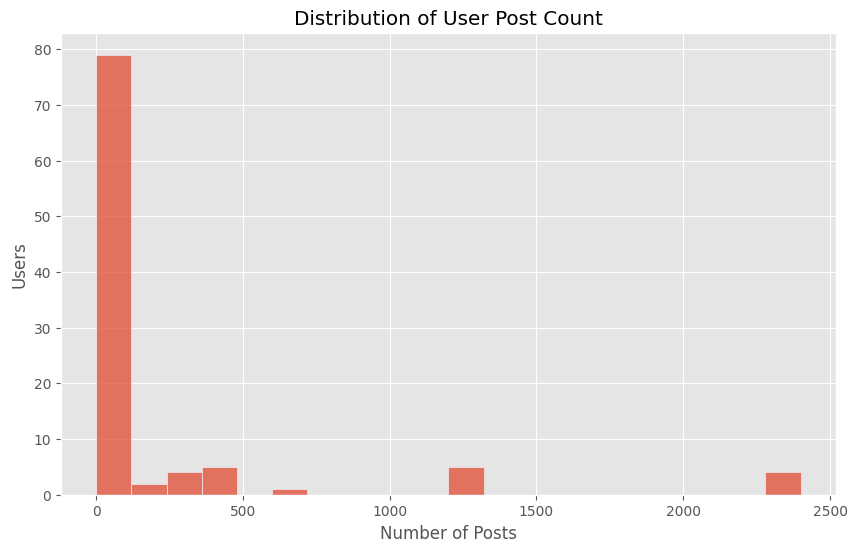

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(
    users["post count"],
    bins=20
)

plt.title("Distribution of User Post Count")

plt.xlabel("Number of Posts")

plt.ylabel("Users")

plt.show()

Analyze Instagram Filters

The frequency of Instagram filters used in posts is visualized to identify the most popular filters.

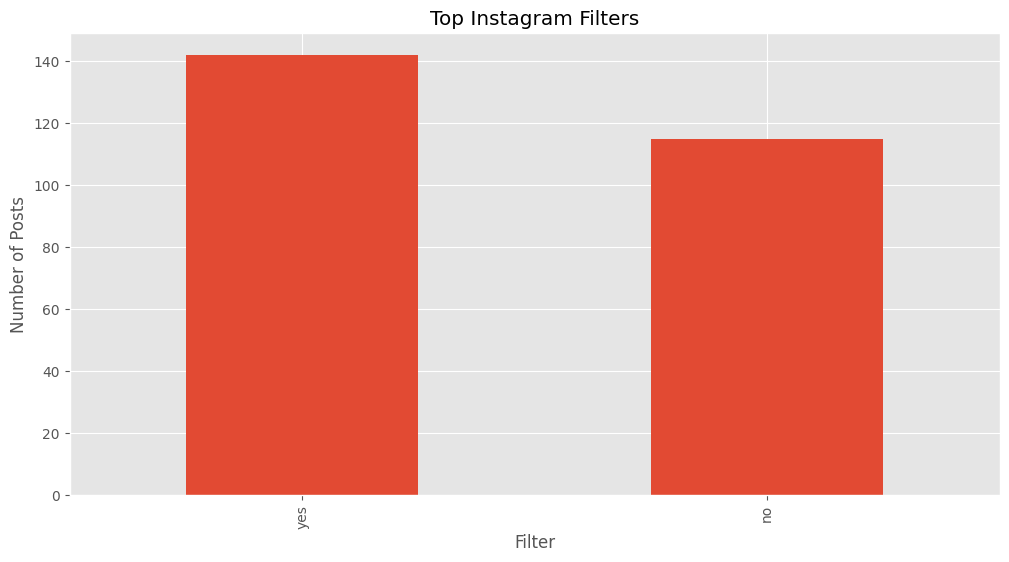

In [32]:
plt.figure(figsize=(12,6))

photos["Insta filter used"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Instagram Filters")

plt.xlabel("Filter")

plt.ylabel("Number of Posts")

plt.show()

Display Overall Engagement Statistics

Basic statistics of likes, comments, and engagement are displayed to summarize audience interaction across all posts.

In [33]:
print("Average Likes")

print(photos["Total Likes"].mean())

print()

print("Average Comments")

print(photos["Total Comments"].mean())

print()

print("Average Engagement")

print(photos["Engagement"].mean())

Average Likes
34.17120622568093

Average Comments
29.136186770428015

Average Engagement
63.30739299610895


Recommended Weekly Content Calendar

Based on engagement analysis, an optimal weekly posting schedule is suggested for improving audience reach and engagement.

In [34]:
calendar = pd.DataFrame({

    "Day":[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ],

    "Recommended Content":[
        "Educational Tips",
        "Product Demo",
        "Behind the Scenes",
        "Customer Stories",
        "Industry News",
        "Reels & Short Videos",
        "Weekly Recap"
    ]

})

calendar

,Day,Recommended Content
0,Monday,Educational Tips
1,Tuesday,Product Demo
2,Wednesday,Behind the Scenes
3,Thursday,Customer Stories
4,Friday,Industry News
5,Saturday,Reels & Short Videos
6,Sunday,Weekly Recap


Display Key Insights

Important insights obtained from the Instagram engagement analysis are summarized below.

In [35]:
print("Top Content Type")

print(photos["photo type"].value_counts().head())

print()

print("Top Filters")

print(photos["Insta filter used"].value_counts().head())

print()

print("Top Active Users")

print(active_users.head())

Top Content Type
photo type
photo       155
video        52
carousel     50
Name: count, dtype: int64

Top Filters
Insta filter used
yes    142
no     115
Name: count, dtype: int64

Top Active Users
user ID
23    12
88    11
59    10
86     9
29     8
dtype: int64


Strategies to Increase Engagement

The following recommendations can help improve Instagram engagement and audience growth for Alfido Tech.

In [36]:
strategies = [

"1. Post consistently during high-engagement days identified from the analysis.",

"2. Increase the use of engaging content such as Reels and carousel posts.",

"3. Use trending hashtags relevant to the target audience in every post.",

"4. Encourage audience interaction through polls, questions, giveaways, and contests.",

"5. Monitor post performance regularly and optimize the content strategy using engagement metrics."

]

for strategy in strategies:

    print(strategy)

1. Post consistently during high-engagement days identified from the analysis.
2. Increase the use of engaging content such as Reels and carousel posts.
3. Use trending hashtags relevant to the target audience in every post.
4. Encourage audience interaction through polls, questions, giveaways, and contests.
5. Monitor post performance regularly and optimize the content strategy using engagement metrics.


Business Recommendation for Alfido Tech

The analysis provides practical recommendations to improve Instagram marketing performance and strengthen customer engagement.

In [37]:
recommendations = [

"Partner with influencers to improve brand visibility.",

"Publish high-quality visual content consistently.",

"Focus on content categories with higher engagement.",

"Use analytics to identify the best posting schedule.",

"Track engagement metrics regularly and refine the marketing strategy."

]

for rec in recommendations:

    print(rec)

Partner with influencers to improve brand visibility.
Publish high-quality visual content consistently.
Focus on content categories with higher engagement.
Use analytics to identify the best posting schedule.
Track engagement metrics regularly and refine the marketing strategy.


Project Conclusion

This project successfully analyzed Instagram engagement using multiple relational datasets. Various visualizations and engagement metrics were used to identify posting patterns, popular hashtags, content performance, and user activity. The insights and recommendations generated from this analysis can help Alfido Tech improve its Instagram marketing strategy, increase audience engagement, and optimize future content planning.

In [38]:
print("="*60)

print("INSTAGRAM ENGAGEMENT ANALYSIS COMPLETED SUCCESSFULLY")

print("="*60)

print()

print("Project Deliverables")

print("✔ Data Cleaning")

print("✔ Engagement Analysis")

print("✔ Posting Schedule Analysis")

print("✔ Hashtag Analysis")

print("✔ Content Type Analysis")

print("✔ Visualizations")

print("✔ Content Calendar")

print("✔ Business Recommendations")

print("✔ Project Conclusion")

INSTAGRAM ENGAGEMENT ANALYSIS COMPLETED SUCCESSFULLY

Project Deliverables
✔ Data Cleaning
✔ Engagement Analysis
✔ Posting Schedule Analysis
✔ Hashtag Analysis
✔ Content Type Analysis
✔ Visualizations
✔ Content Calendar
✔ Business Recommendations
✔ Project Conclusion
